# EDA: macro_stress_scenarios.csv

This notebook explores the raw `macro_stress_scenarios.csv` file. It is at a different
level of detail than `macro_scenarios.csv`: each row here is a scenario and sector
combination, with a PD multiplier and an LGD figure for that sector under that
scenario, rather than one row per scenario overall. This is the file that turns a
macro shock into a sector-specific risk adjustment.

This notebook only explores and records data-quality issues. Cleaning happens in
`notebooks/data_cleaning.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and inspect

In [2]:
raw = pd.read_csv('../raw/macro_stress_scenarios.csv', dtype=str, keep_default_na=False)
print('shape:', raw.shape)
raw.head()

shape: (60, 11)


,scenario,sector,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,inflation_shock_pp,fx_devaluation_pct,pd_multiplier,base_lgd,stressed_lgd
0,baseline,Technology,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.5
1,baseline,Healthcare,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.35,0.35
2,baseline,Real_Estate,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.35,0.35
3,baseline,Energy,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.45,0.45
4,baseline,Industrials,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.4,0.4


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   scenario            60 non-null     object
 1   sector              60 non-null     object
 2   gdp_shock_pp        60 non-null     object
 3   unemp_shock_pp      60 non-null     object
 4   rate_shock_pp       60 non-null     object
 5   credit_spread_bps   60 non-null     object
 6   inflation_shock_pp  60 non-null     object
 7   fx_devaluation_pct  60 non-null     object
 8   pd_multiplier       60 non-null     object
 9   base_lgd            60 non-null     object
 10  stressed_lgd        60 non-null     object
dtypes: object(11)
memory usage: 5.3+ KB


## 2. scenario labels, and the gap with macro_scenarios.csv

In [4]:
print('Unique scenario labels:')
print(sorted(raw['scenario'].unique()))

Unique scenario labels:
['ADVERSE', 'GFC_LIKE', 'Mild', 'adverse', 'adverse ', 'baseline', 'baseline ', 'covid_like', 'covid_like ', 'gfc_like', 'gfc_like ', 'mild', 'severe']


**Conclusion, and an important caveat for the whole project.** The `scenario`
column mixes two different ideas. Five of the values (`baseline`, `mild`, `adverse`,
`severe`, and a variant spelling of one of them) are the same severity levels used in
`macro_scenarios.csv`. There is no `moderate` row in this file. The other two values,
`gfc_like` and `covid_like`, are named historical scenarios (modelled loosely on the
2008 financial crisis and the COVID-19 shock) that do not exist anywhere in
`macro_scenarios.csv` and are not attached to any `scenario_id`.

In practice this means the 500 scenarios tested against every bank in
`bank_stress_simulated_panel.csv` never actually include `gfc_like` or `covid_like`.
Those two named scenarios only exist here, as reference PD and LGD multipliers by
sector, and are not part of the main 40-bank by 500-scenario stress run. Anyone using
this data should not assume the panel's results already cover a GFC-style or
COVID-style shock. They do not, at least not under those names.

## 3. Sector labels

In [5]:
print('Unique sector labels:')
print(sorted(raw['sector'].unique()))

Unique sector labels:
['Consumer', 'Consumer Goods', 'Energy', 'Finance', 'Financial', 'Financials', 'Health Care', 'Healthcare', 'Industrial', 'Industrials', 'Real_Estate', 'Retail', 'Retial', 'Tech', 'Technology', 'Tele Com', 'Telecom', 'Utilities', 'Utility']


**Conclusion.** Unlike `loan_portfolio.csv`, the sector labels here are much closer
to clean: the same 10 sectors, mostly consistent casing, with a small number of rows
using an abbreviation or an alternate spelling (`Tech`, `Retial`, `Tele Com`,
`Utility`, `Finance`, `Health Care`, `Financial`, `Consumer Goods`, `Industrial`)
rather than the standard label. These need the same kind of mapping used for
`loan_portfolio.csv`, just for far fewer rows.

## 4. Numeric fields stored as text

In [6]:
def non_numeric_values(series):
    out = []
    for v in series.unique():
        cleaned = v.strip()
        if cleaned == '':
            out.append(v)
            continue
        try:
            float(cleaned)
        except ValueError:
            out.append(v)
    return out

for col in ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
            'inflation_shock_pp', 'fx_devaluation_pct', 'pd_multiplier',
            'base_lgd', 'stressed_lgd']:
    bad = non_numeric_values(raw[col])
    print(f'{col}: {len(bad)} problem value(s), examples: {bad[:6]}')

gdp_shock_pp: 0 problem value(s), examples: []
unemp_shock_pp: 0 problem value(s), examples: []
rate_shock_pp: 0 problem value(s), examples: []
credit_spread_bps: 0 problem value(s), examples: []
inflation_shock_pp: 0 problem value(s), examples: []
fx_devaluation_pct: 0 problem value(s), examples: []
pd_multiplier: 2 problem value(s), examples: ['NA', '']
base_lgd: 0 problem value(s), examples: []
stressed_lgd: 0 problem value(s), examples: []


**Conclusion.** All numeric columns already parse cleanly as numbers once read.
The only remaining step is converting their dtype from text to float, there is no
symbol stripping or token replacement needed here.

## 5. Duplicate rows

In [7]:
print('Fully duplicated rows:', raw.duplicated().sum())

Fully duplicated rows: 0


**Conclusion.** There are no duplicate rows in this file.

## 6. pd_multiplier by scenario

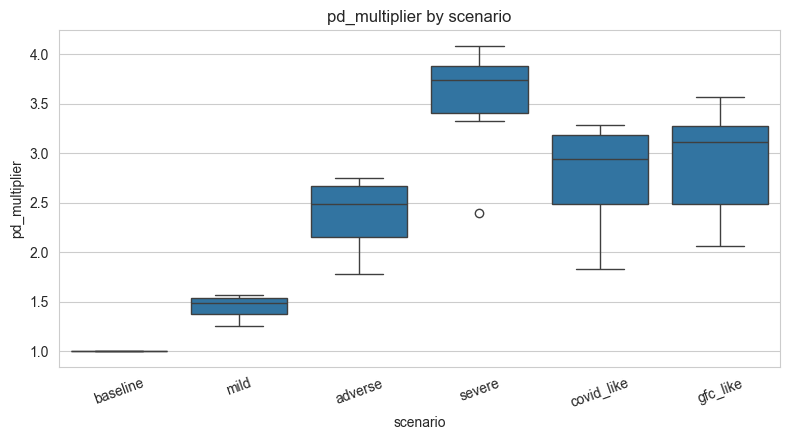

In [8]:
stress_preview = raw.copy()
stress_preview['scenario'] = stress_preview['scenario'].str.strip().str.lower()
stress_preview['pd_multiplier'] = pd.to_numeric(stress_preview['pd_multiplier'], errors='coerce')

order = ['baseline', 'mild', 'adverse', 'severe', 'covid_like', 'gfc_like']
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=stress_preview, x='scenario', y='pd_multiplier', order=order, ax=ax)
ax.set_title('pd_multiplier by scenario')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Conclusion.** `pd_multiplier` rises sharply for `gfc_like` and `covid_like`,
well past the `severe` level. This fits their purpose as reference points for the worst
historical episodes, sitting outside the mild-to-severe scale rather than as one more
step on it.

## 7. pd_multiplier by sector

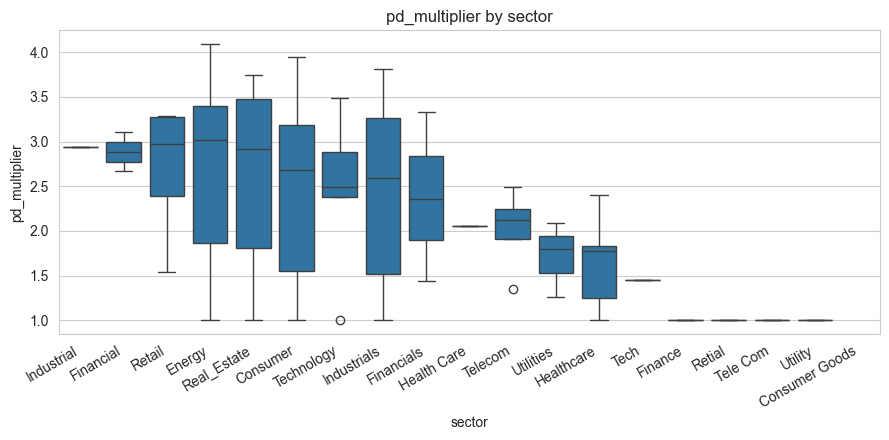

In [9]:
sector_order = stress_preview.groupby('sector')['pd_multiplier'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=stress_preview, x='sector', y='pd_multiplier', order=sector_order, ax=ax)
ax.set_title('pd_multiplier by sector')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Conclusion.** Sectors that are usually seen as more cyclical, such as energy and
real estate, tend to carry a higher `pd_multiplier` than steadier sectors such as
utilities and consumer. This lines up with the sector-level PD pattern already seen in
`loan_portfolio.csv`, so the two files agree with each other on which sectors are
riskier under stress.

## 8. Correlation between shocks and outcomes

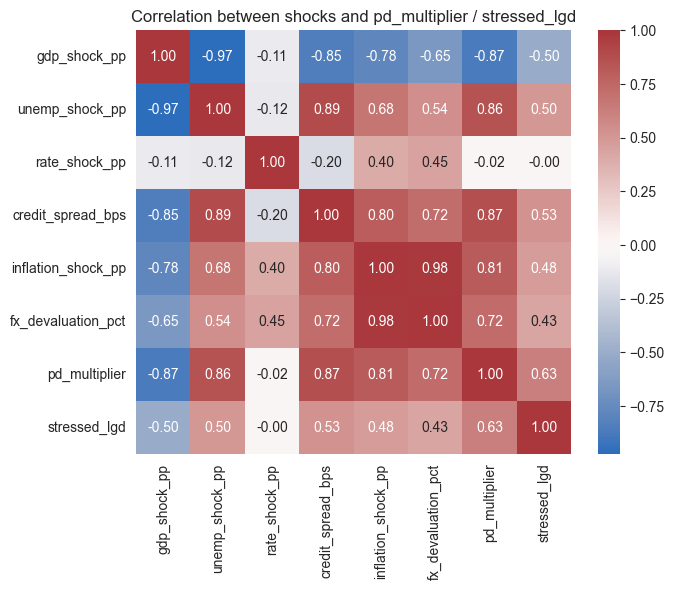

In [10]:
num_cols = ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
            'inflation_shock_pp', 'fx_devaluation_pct', 'pd_multiplier', 'stressed_lgd']
numeric_preview = stress_preview[num_cols].apply(pd.to_numeric, errors='coerce')
corr = numeric_preview.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlation between shocks and pd_multiplier / stressed_lgd')
plt.tight_layout()
plt.show()

**Conclusion.** `credit_spread_bps` and `rate_shock_pp` show the strongest positive
relationship with `pd_multiplier`, which makes sense since both are direct signals of
tightening credit conditions. `stressed_lgd` moves with the same variables but less
strongly, suggesting the simulation treats default probability as more sensitive to the
shock size than loss severity is.

## Summary of issues found

- No duplicate rows.
- `scenario` mixes the five severity levels with two named historical scenarios
  (`gfc_like`, `covid_like`) that are not present in `macro_scenarios.csv` and are not
  tested in the main 40-bank by 500-scenario run. This gap is worth remembering when
  interpreting project results, not something that gets "fixed" by cleaning.
- `sector` needs minor whitespace and underscore normalisation.
- All numeric columns need a dtype conversion but no symbol cleanup.

All of these are handled in `notebooks/data_cleaning.ipynb`, which writes the cleaned
result to `processed/macro_stress_scenarios_clean.csv`.